<a href="https://colab.research.google.com/github/YLysov0017/PETUXON/blob/master/ML_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install tensorflow

In [2]:
from sklearn.datasets import load_iris
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

#### Установка персонального параметра генератора сл. чисел!!!

In [3]:
from tensorflow.keras.utils import set_random_seed

set_random_seed( 8 )

# для абсолютной повторяемости желательно еще включать детерминизм, особно при работе на GPU,
#но пока можно ограничиться только set_random_seed
#tf.config.experimental.enable_op_determinism()

#### Загрузка набора данных

In [4]:
ds = pd.read_csv('/content/classify08.csv')

In [5]:
ds

,Свойство1,Свойство2,Свойство3,Свойство4,Класс
0,-3.402839,0.179845,1.432424,0.774566,1
1,-1.902995,-1.241501,1.956614,0.512447,1
2,-1.023094,1.270126,0.782203,-0.785725,0
3,-0.331077,-0.069590,-0.258279,-0.339054,0
4,-3.377452,0.816699,-3.009166,-1.553258,2
...,...,...,...,...,...
195,-0.104947,1.062210,-0.376616,-0.015822,2
196,-0.940820,-0.057905,-1.127248,-0.804252,2
197,0.492343,-0.883778,0.855732,1.910750,1
198,0.676033,1.315767,1.915142,2.628719,1


In [55]:
x = ds[['Свойство1', 'Свойство2', 'Свойство3', 'Свойство4']]
y = ds['Класс']

#### предобработка данных:
* нормирование / стандартизация входов
* кодирование выходов
* разделение данных на обучающий и тестовые наборы

In [36]:
xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

In [37]:
ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

In [38]:
xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

#### построение модели ИНС путем последовательного описания слоев в форме списка

In [34]:
nn = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 12, activation = "relu" ),
    Dense( units = 6, activation = "relu" ),
    Dense( units = 4, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] )

nn.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

#### обучение модели на обучающем наборе с валидацией по 10% от обучающей выборки (последние 10% прмиеров)

In [52]:
hist = nn.fit( xTrain, yTrain, epochs = 40, batch_size = 8, validation_split = 0.1 )

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.5250 - loss: 0.8831 - val_categorical_accuracy: 0.5714 - val_loss: 0.9157
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.5583 - loss: 0.8671 - val_categorical_accuracy: 0.5714 - val_loss: 0.9095
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.5667 - loss: 0.8547 - val_categorical_accuracy: 0.5714 - val_loss: 0.9053
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.5667 - loss: 0.8419 - val_categorical_accuracy: 0.5714 - val_loss: 0.9017
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.5667 - loss: 0.8290 - val_categorical_accuracy: 0.5714 - val_loss: 0.8980
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.5667 - loss: 0.8166 - val_categorical_accuracy: 0.5714 - val_loss: 0.8946
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.5750 - loss: 0.8046 

#### визуализация метрик

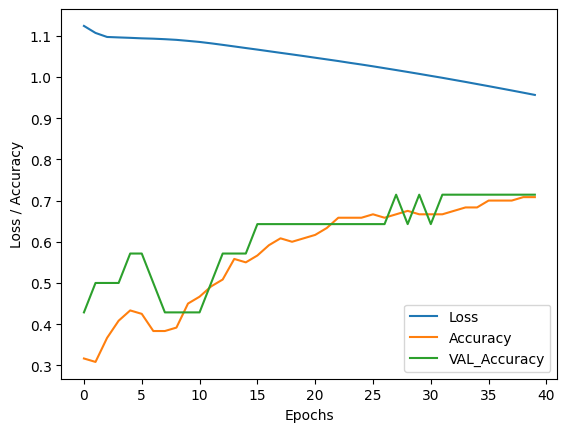

In [12]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

#### оценка модели на тестовом наборе

In [13]:
nn.evaluate(xTest, yTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.7273 - loss: 0.9396


[0.9396252036094666, 0.7272727489471436]

#### использование модели для предсказания на произвольном примере (предоставление одного примера)

In [15]:
# "произвольный" пример возьмем из тестового набора

sampleIndex = 19
yPred = nn.predict( xTest.to_numpy()[ sampleIndex ].reshape(1,-1) ) # важно преобразовать 1 пример к массиву из 1 элемента (довавить 1 измерение)

predLabel = np.argmax( yPred )
actLabel = np.where(yTest[sampleIndex] == 1)[0][0]
print(f"Предсказание: {predLabel}, На самом деле: {int(actLabel)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Предсказание: 2, На самом деле: 2


In [16]:
# посмтореть на сырой выход нейросети
yPred

array([[0.3651176 , 0.17738578, 0.45749664]], dtype=float32)

### Классификация без One-Hot

Используем *xNorm* на входе и "родной" *y* с номерами меток на выходе

In [46]:
x_train, x_test, y_train, y_test = train_test_split( xNorm, y, train_size = 0.67 )

Чтобы использовать метки, не прибегая к их бинарному кодированию, используем функцию потерь **sparse_categorical_crossentropy**

Однако на выходе нейросети должны по-прежнему быть три классифицирующих нейрона (sigmoid или softmax)

In [25]:
nnSparse = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 12, activation = "relu" ),
    Dense( units = 8, activation = "relu" ),
    Dense( units = len(np.unique(y)), activation = "softmax" )
] )

nnSparse.compile( loss = "sparse_categorical_crossentropy",
            optimizer = "adam", metrics = ["sparse_categorical_accuracy"] )

In [26]:
hist = nnSparse.fit( x_train, y_train, epochs = 100, batch_size = 10 )

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0928 - sparse_categorical_accuracy: 0.2612    
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0738 - sparse_categorical_accuracy: 0.3060 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0558 - sparse_categorical_accuracy: 0.3582     
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0378 - sparse_categorical_accuracy: 0.3881 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0225 - sparse_categorical_accuracy: 0.4701 
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0090 - sparse_categorical_accuracy: 0.5149 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9982 - sparse_categorical_accuracy: 0.5075 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9887 - sparse_categorical_accuracy: 0.5075 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9796 - sparse_categorical_accuracy: 0.5299 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

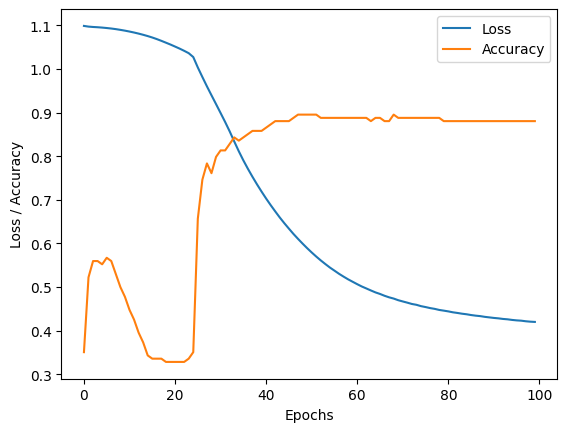

In [20]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["sparse_categorical_accuracy"], label = "Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

In [21]:
nnSparse.evaluate( x_test, y_test )

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5136 - sparse_categorical_accuracy: 0.8182 


[0.5136464238166809, 0.8181818127632141]

### Работа с переобучением модели

Искусственно создаем переобученную модель и без изменения ее структуры (количество нейронов в слоях) добиваемся снижения эффекта переобучения:
* Слои прореживания Dropout
* L1, L2, L1L2 регуляризация

In [62]:
ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

nnOver = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu" ),
    Dense( units = 128, activation = "relu" ),
    Dense( units = 64, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Намеренно огромное кол-во нейронов

nnOver.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [63]:
hist = nn.fit( xTrain, yTrain, epochs = 400, batch_size = 10, validation_split = 0.1 ) # Много эпох

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.7000 - loss: 0.6626 - val_categorical_accuracy: 0.7857 - val_loss: 0.6102
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.6833 - loss: 0.6509 - val_categorical_accuracy: 0.8571 - val_loss: 0.6273
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6583 - loss: 0.6472 - val_categorical_accuracy: 0.7143 - val_loss: 0.6390
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.6750 - loss: 0.6462 - val_categorical_accuracy: 0.7143 - val_loss: 0.6400
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.6750 - loss: 0.6436 - val_categorical_accuracy: 0.7143 - val_loss: 0.6405
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.6667 - loss: 0.6414 - val_categorical_accuracy: 0.7143 - val_loss: 0.6418
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.6667 - loss: 0.6

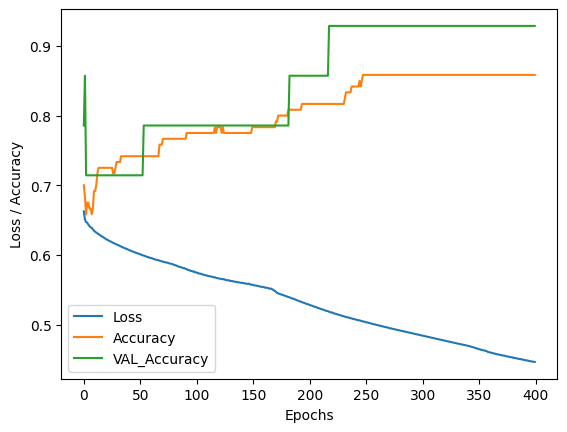

In [64]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

### Чиним безобразие

In [ ]:
from tensorflow.keras.layers import Dropout
nnOverHealed = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu" ),
    Dropout(0.5),
    Dense( units = 128, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.001) ),
    Dropout(0.5),
    Dense( units = 64, activation = "relu" ),
    Dropout(0.5),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Отключаем случайную половину нейронов

nnOverHealed.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )